# Signals and Their Properties with Python
Solutions for common Signals & Systems Online-1 problems.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]=(8,3)

def stem_plot(n,x,title):
    plt.figure()
    plt.stem(n,x,basefmt=" ")
    plt.grid(True)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel("Amplitude")
    plt.show()


## 1. Signal Generation

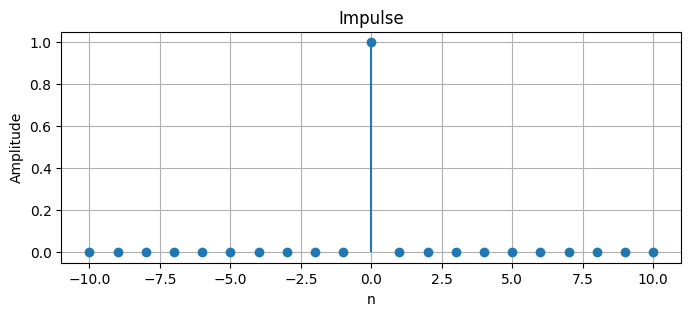

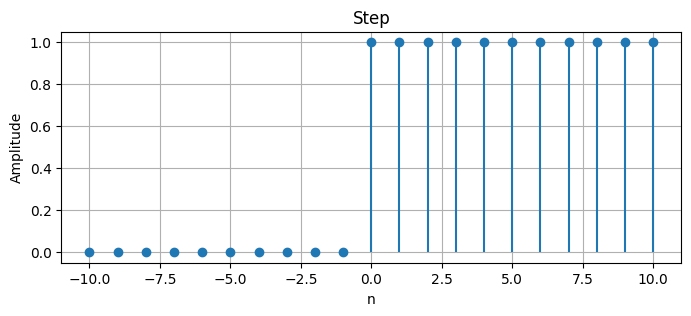

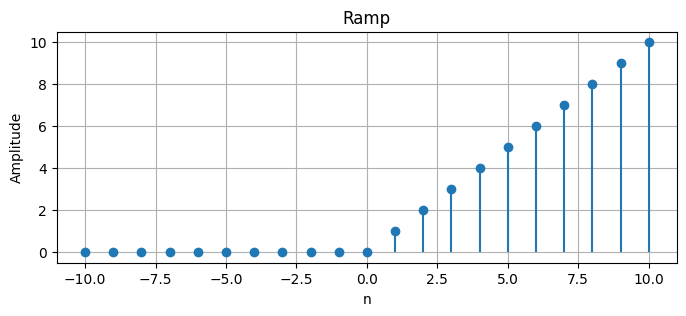

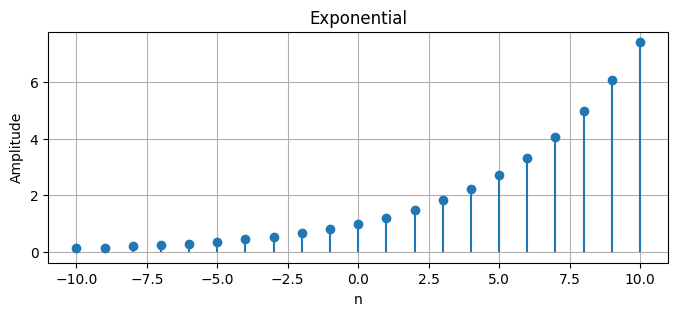

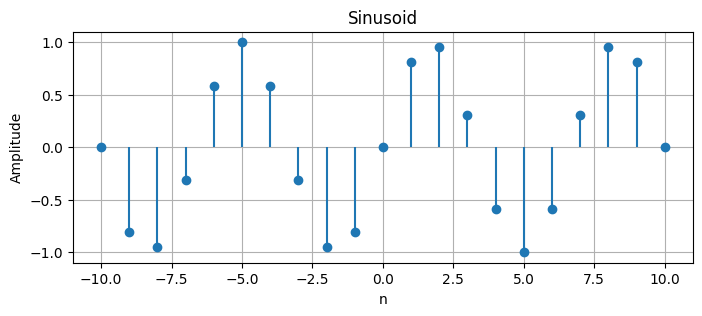

In [2]:

n=np.arange(-10,11)
imp=(n==0).astype(int)
step=(n>=0).astype(int)
ramp=np.maximum(n,0)
exp=np.exp(0.2*n)
sin=np.sin(0.3*np.pi*n)
for s,t in [(imp,"Impulse"),(step,"Step"),(ramp,"Ramp"),(exp,"Exponential"),(sin,"Sinusoid")]:
    stem_plot(n,s,t)


## 2. Time Shift

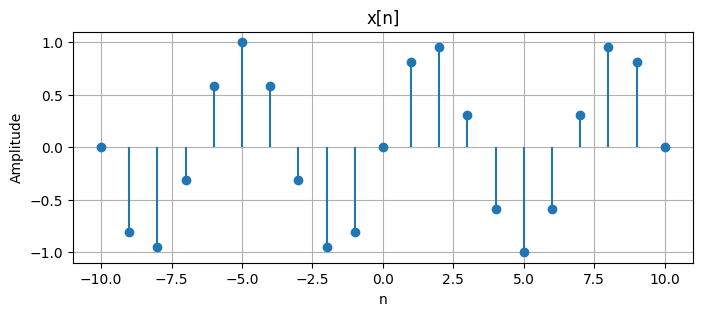

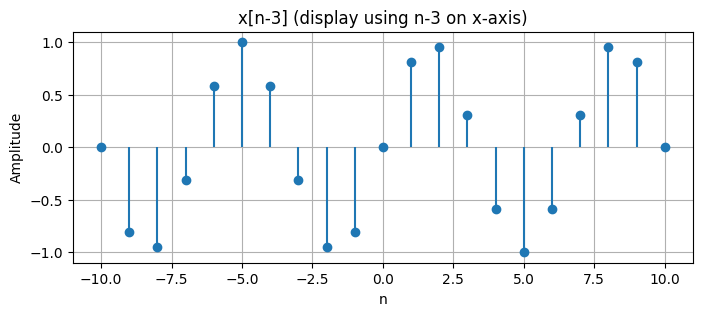

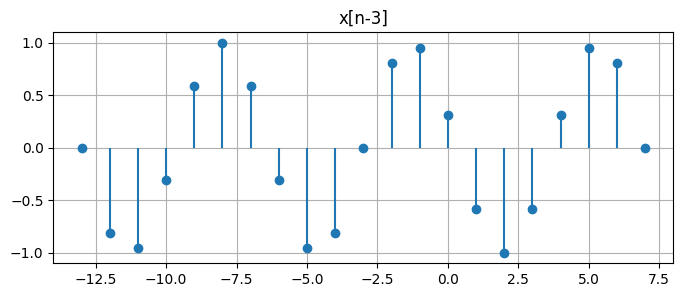

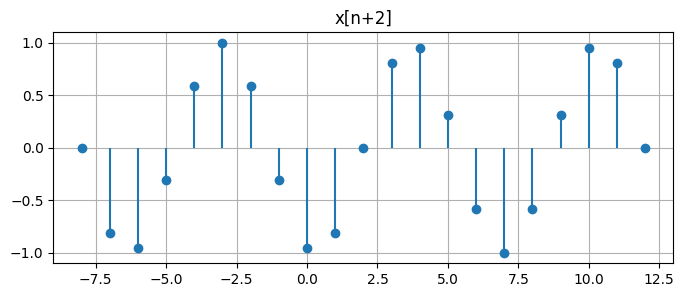

In [3]:

n=np.arange(-10,11)
x=np.sin(0.3*np.pi*n)
stem_plot(n,x,"x[n]")
stem_plot(n,x,"x[n-3] (display using n-3 on x-axis)")
plt.figure(); plt.stem(n-3,x,basefmt=" "); plt.grid(); plt.title("x[n-3]"); plt.show()
plt.figure(); plt.stem(n+2,x,basefmt=" "); plt.grid(); plt.title("x[n+2]"); plt.show()


## 3. Time Reversal

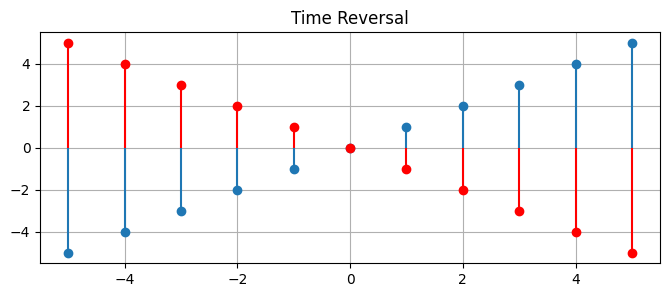

In [4]:

n=np.arange(-5,6)
x=n.copy()
plt.figure()
plt.stem(n,x,label="x[n]",basefmt=" ")
plt.stem(-n,x,linefmt="r-",markerfmt="ro",basefmt=" ")
plt.grid(); plt.title("Time Reversal"); plt.show()


## 4. Time Scaling

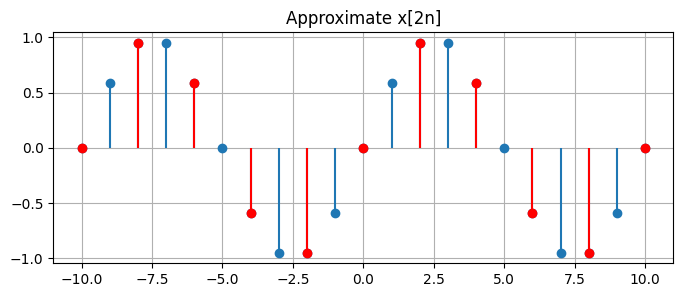

In [5]:

n=np.arange(-10,11)
x=np.sin(0.2*np.pi*n)
plt.figure()
plt.stem(n,x,basefmt=" ",label="x[n]")
plt.stem(n[::2],x[::2],linefmt="r-",markerfmt="ro",basefmt=" ")
plt.title("Approximate x[2n]"); plt.grid(); plt.show()


## 5. Amplitude Scaling

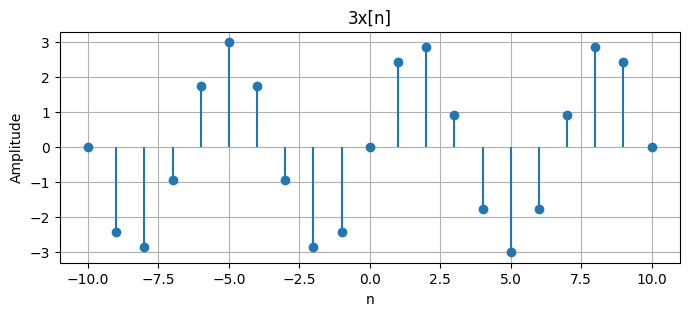

In [6]:
n=np.arange(-10,11)
x=np.sin(0.3*np.pi*n)
stem_plot(n,3*x,'3x[n]')

## 6. Even/Odd Decomposition

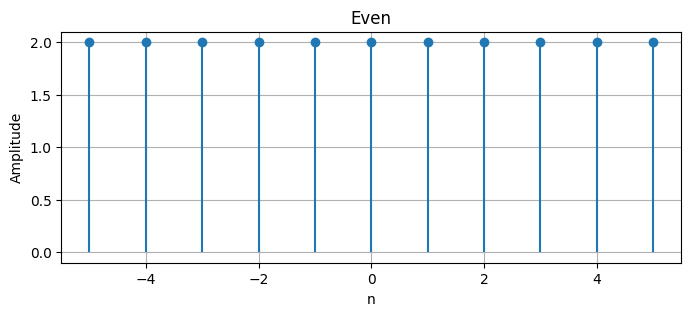

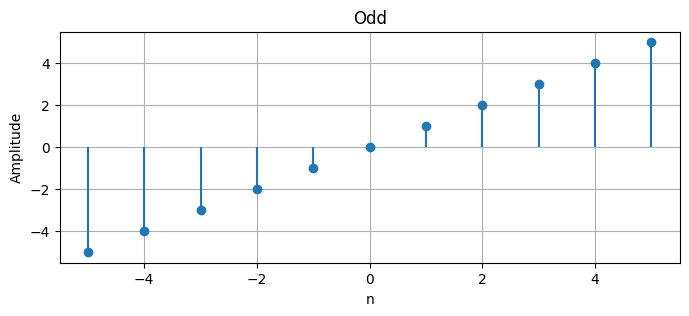

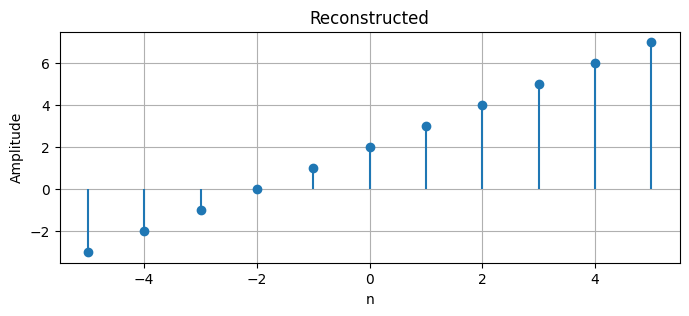

In [7]:

n=np.arange(-5,6)
x=n+2
xe=(x+x[::-1])/2
xo=(x-x[::-1])/2
stem_plot(n,xe,"Even")
stem_plot(n,xo,"Odd")
stem_plot(n,xe+xo,"Reconstructed")


## 7. Energy and Power

In [8]:

n=np.arange(-10,11)
x=(n>=0).astype(float)
E=np.sum(np.abs(x)**2)
P=np.mean(np.abs(x)**2)
print("Energy =",E)
print("Power =",P)


Energy = 11.0
Power = 0.5238095238095238


## 8. Periodicity

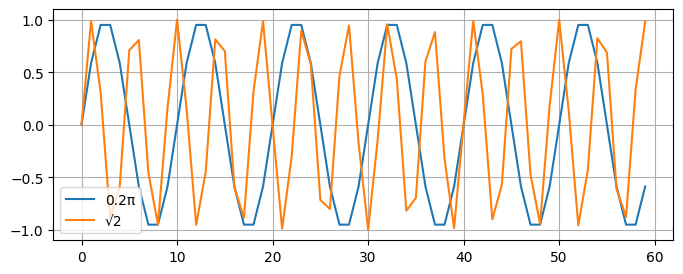

First is periodic (N=10). Second is not periodic.


In [9]:

n=np.arange(0,60)
x1=np.sin(0.2*np.pi*n)
x2=np.sin(np.sqrt(2)*n)
plt.plot(n,x1,label="0.2π")
plt.plot(n,x2,label="√2")
plt.legend(); plt.grid(); plt.show()
print("First is periodic (N=10). Second is not periodic.")


## 9. Phase Shift

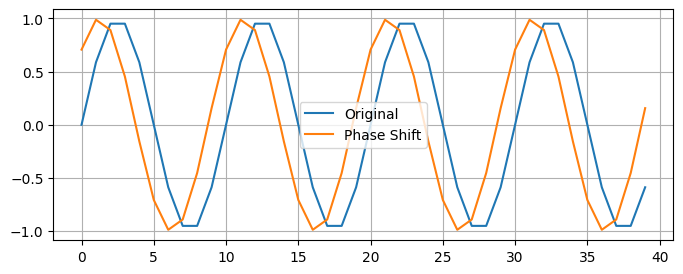

In [10]:
n=np.arange(0,40)
plt.plot(n,np.sin(0.2*np.pi*n),label='Original')
plt.plot(n,np.sin(0.2*np.pi*n+np.pi/4),label='Phase Shift')
plt.legend(); plt.grid(); plt.show()

## 10. Linear Combination

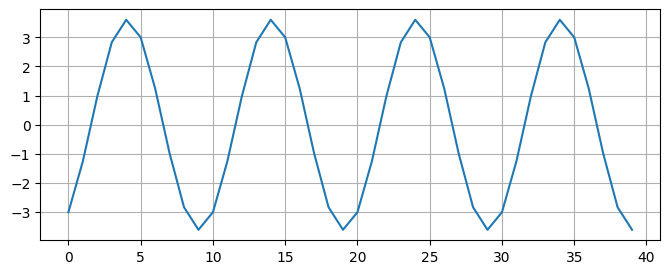

In [11]:
n=np.arange(0,40)
x1=np.sin(.2*np.pi*n); x2=np.cos(.2*np.pi*n); y=2*x1-3*x2
plt.plot(n,y); plt.grid(); plt.show()

## 11. Causality

In [12]:
print('y[n]=x[n]+x[n-2] -> Causal')
print('y[n]=x[n+1] -> Non-causal')

y[n]=x[n]+x[n-2] -> Causal
y[n]=x[n+1] -> Non-causal


## 12. Linearity Verification

In [13]:

x1=np.random.randn(20); x2=np.random.randn(20); a,b=2,-1
lhs=2*(a*x1+b*x2)
rhs=a*(2*x1)+b*(2*x2)
print(np.allclose(lhs,rhs))
print("x^2 is non-linear.")


True
x^2 is non-linear.


## 13. Time Invariance

In [14]:

x=np.random.randn(20)
k=3
y=x+np.roll(x,1)
yshift=np.roll(y,k)
test=np.roll(x,k)+np.roll(np.roll(x,k),1)
print(np.allclose(yshift,test))
print("System y=x+x[n-1] is time invariant.")
print("System y=n*x[n] is time varying.")


True
System y=x+x[n-1] is time invariant.
System y=n*x[n] is time varying.


## 14. Signal Transformation Tool

In [ ]:

choice=int(input("1:Shift 2:Reverse 3:Scale: "))
n=np.arange(-10,11)
x=np.sin(.2*np.pi*n)
if choice==1:
    k=int(input("Shift: "))
    plt.stem(n-k,x,basefmt=" ")
elif choice==2:
    plt.stem(-n,x,basefmt=" ")
elif choice==3:
    a=float(input("Scale: "))
    plt.stem(n,a*x,basefmt=" ")
plt.grid(); plt.show()


## 15. Interactive Playground

In [ ]:
print('Use ipywidgets or matplotlib.widgets sliders for amplitude, frequency and phase.')

## 16. Multiple Operations

In [ ]:

n=np.arange(-10,11)
x=np.sin(.2*np.pi*n)
fig,axs=plt.subplots(2,3,figsize=(10,6))
ops=[(n,x,'Original'),(n-3,x,'Delay'),(n+3,x,'Advance'),(-n,x,'Reverse'),(n,2*x,'Scale'),(-n+2,2*x,'Reverse+Shift')]
for ax,(xn,y,t) in zip(axs.ravel(),ops):
    ax.stem(xn,y,basefmt=" ")
    ax.set_title(t); ax.grid()
plt.tight_layout(); plt.show()


## 17. Quiz Generator

In [ ]:

import random
ops=["Delay","Advance","Reverse","Scale"]
ans=random.choice(ops)
print("Random operation:",ans)


## 18. System Property Checker

In [ ]:

systems={
"y=x+x[n-1]":("Yes","Yes","Yes"),
"y=x[n+1]":("No","Yes","Yes"),
"y=nx[n]":("Yes","Yes","No"),
"y=x^2[n]":("Yes","No","Yes"),
"y=|x[n]|":("Yes","No","Yes"),
"y=x[-n]":("No","Yes","No")
}
for k,v in systems.items():
    print(f"{k:15} Causal:{v[0]} Linear:{v[1]} TI:{v[2]}")
